In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:

df = pd.read_csv("churn_dataset.csv")
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe

<bound method NDFrame.describe of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DS

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].isnull().sum()

df = df.dropna()

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

1. Target Variable – Churn Distribution

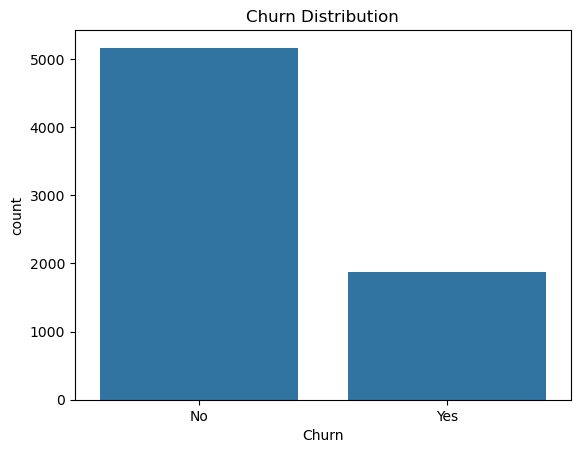

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

In [9]:
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

df["Churn"].value_counts(normalize=True) * 100


Around 25–30% customers churn.

Dataset is slightly imbalanced.

Retention strategy is required.

2. Numerical Feature Distribution

Tenure


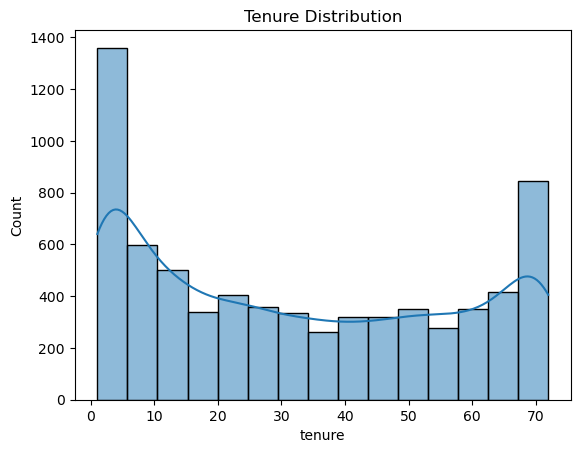

In [10]:
sns.histplot(df["tenure"], kde=True)
plt.title("Tenure Distribution")
plt.show()


Insight:

Many customers are new (low tenure).

Risk of churn higher in early months.

MonthlyCharges

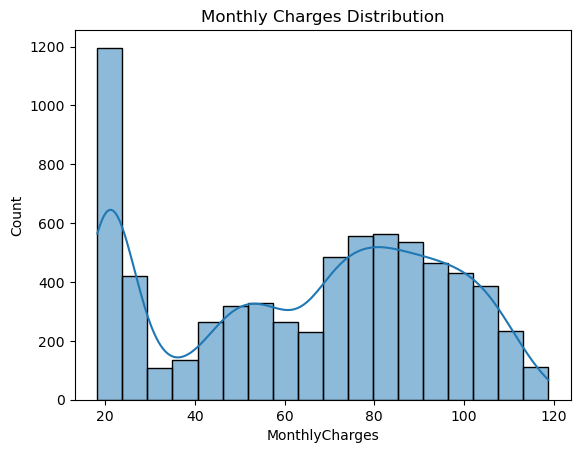

In [11]:
sns.histplot(df["MonthlyCharges"], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()


Insight:

Wide variation in charges.

Some customers paying very high monthly fees.

TotalCharges

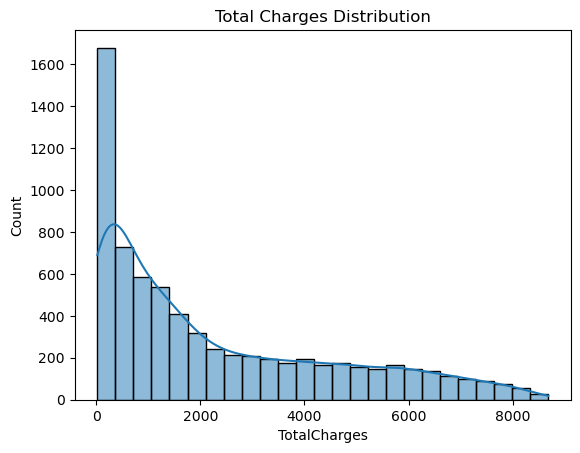

In [12]:
sns.histplot(df["TotalCharges"], kde=True)
plt.title("Total Charges Distribution")
plt.show()


Insight:

Right-skewed distribution.

Long-term customers pay higher total.

BIVARIATE ANALYSIS (Feature vs Churn)

1. Tenure vs Churn

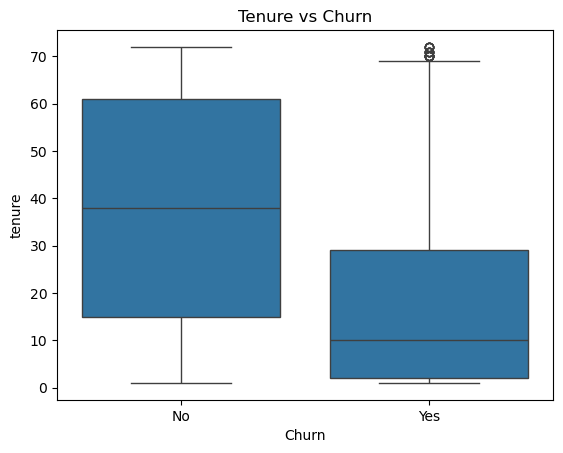

In [13]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

- Customers with low tenure churn more
- Long-term customers rarely churn

- Business: Focus on first 6 months retention strategy.

2. Contract Type vs Churn

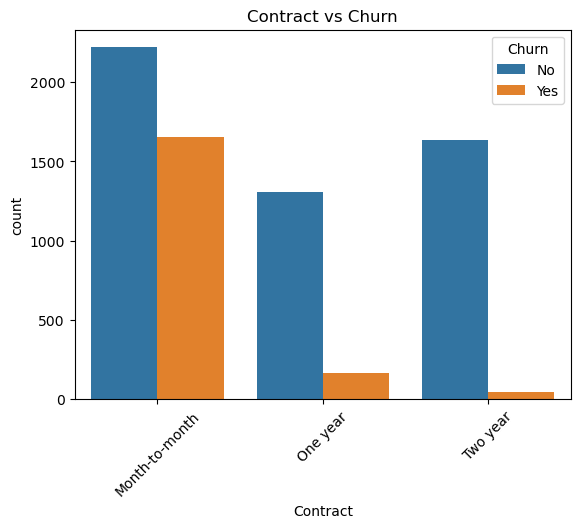

In [14]:
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Contract vs Churn")
plt.show()

Insight:

- Month-to-month → Highest churn
- 2-year contract → Lowest churn
- Business: Promote long-term contracts.

3. MonthlyCharges vs Churn

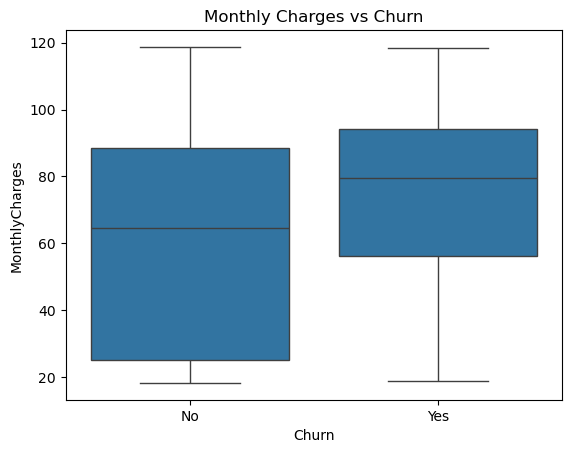

In [15]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Insight:

- Higher monthly charges → Higher churn
- Business: Offer pricing optimization or discounts.

4. InternetService vs Churn

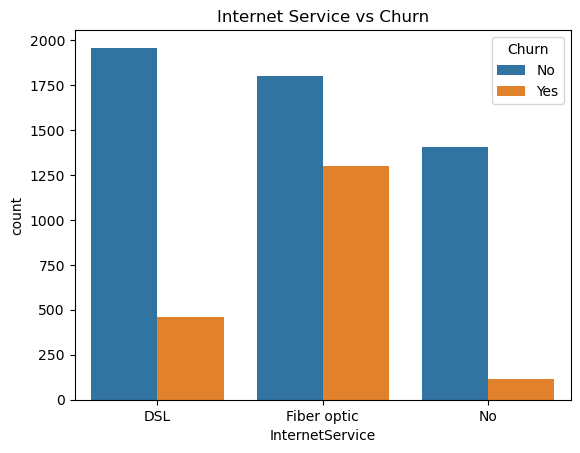

In [16]:
sns.countplot(x="InternetService", hue="Churn", data=df)
plt.title("Internet Service vs Churn")
plt.show()

Insight:

- Fiber optic customers churn more
- Business: Improve fiber service quality.

5. TechSupport vs Churn

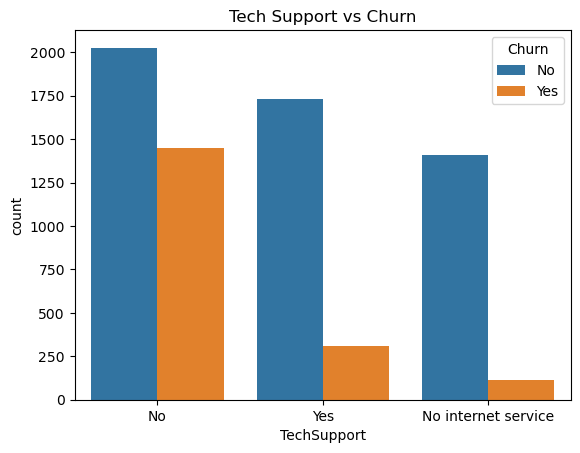

In [17]:
sns.countplot(x="TechSupport", hue="Churn", data=df)
plt.title("Tech Support vs Churn")
plt.show()

Insight:

- Customers without tech support churn more
- Business: Bundle tech support.

6. PaymentMethod vs Churn

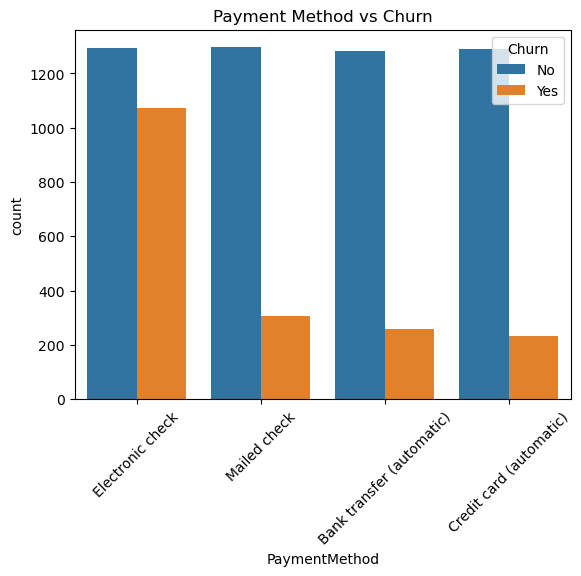

In [18]:
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()


Insight:

- Electronic check users churn most
- Business: Encourage auto-payment.

MULTIVARIATE ANALYSIS

1. Tenure + Contract + Churn

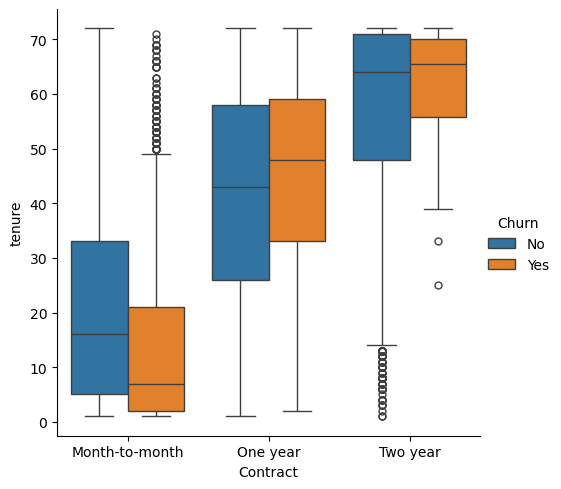

In [19]:
sns.catplot(x="Contract", y="tenure", hue="Churn", data=df, kind="box")
plt.show()

Insight:

- Month-to-month + Low tenure = Highest churn segment
- High-risk customer profile identified

2. Correlation (Numerical Only)

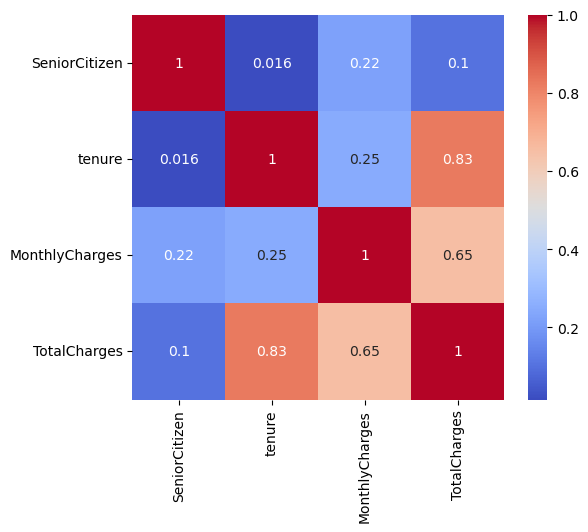

In [20]:
plt.figure(figsize=(6,5))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

Insight:

- Tenure strongly related to TotalCharges
- MonthlyCharges moderately related to churn

3. Churn Rate by Contract (%)

In [21]:
contract_churn = pd.crosstab(df["Contract"], df["Churn"], normalize="index") * 100
print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


Month-to-month churn rate is extremely high compared to 2-year contract.